# RideSmart: Modelagem e Análise de Rotas Urbanas com Grafos
## Notebook de Implementação, Simulação e Análise Experimental

Este notebook contém o desenvolvimento completo do projeto **RideSmart**, elaborado para a Unidade III da disciplina de **Algoritmos e Estruturas de Dados II (DCA0209)**.

### Grupo:
* **ICARO BRUNO SILBE CORTÊS**
* **GABRIEL SEBASTIAO DO NASCIMENTO NETO**
* **SARA GABRIELLY DO NASCIMENTO SILVA**

---

## 1. Importações e Configurações

In [69]:
import time
import math
import heapq
import random
import osmnx as ox
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

# Configurar sementes randômicas para reprodutibilidade
random.seed(42)
np.random.seed(42)

## 2. Implementação dos Algoritmos de Caminhos Mínimos

Implementações manuais construídas a partir do zero utilizando estruturas básicas de Python:

In [70]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula a distância do grande círculo entre dois pontos na Terra em metros.
    """
    R = 6371000.0  # Raio da Terra em metros
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    
    a = math.sin(delta_phi / 2.0) ** 2 + \
        math.cos(phi1) * math.cos(phi2) * \
        math.sin(delta_lambda / 2.0) ** 2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))
    return R * c

def dijkstra_simple(graph, start, end, weight_field='length'):
    """
    Dijkstra simples utilizando busca linear para encontrar o nó mínimo (O(V^2)).
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    distances = {node: float('inf') for node in graph.nodes}
    distances[start] = 0
    predecessors = {node: None for node in graph.nodes}
    unvisited = set(graph.nodes)
    path_found = False
    
    while unvisited:
        current_node = min(unvisited, key=lambda n: distances[n])
        
        if distances[current_node] == float('inf') or current_node == end:
            if current_node == end:
                path_found = True
            break
            
        unvisited.remove(current_node)
        nodes_expanded += 1
        
        for neighbor in graph.neighbors(current_node):
            if neighbor not in unvisited:
                continue
            weight = graph[current_node][neighbor].get(weight_field, float('inf'))
            new_dist = distances[current_node] + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                predecessors[neighbor] = current_node
                
    path = []
    if path_found or distances[end] != float('inf'):
        curr = end
        while curr is not None:
            path.append(curr)
            curr = predecessors[curr]
        path.reverse()
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': distances[end] if distances[end] != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

def dijkstra_heap(graph, start, end, weight_field='length'):
    """
    Dijkstra utilizando min-heap como fila de prioridades (O((V+E) log V)).
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    distances = {node: float('inf') for node in graph.nodes}
    distances[start] = 0
    predecessors = {node: None for node in graph.nodes}
    pq = [(0, start)]
    visited = set()
    path_found = False
    
    while pq:
        dist, current_node = heapq.heappop(pq)
        if current_node in visited:
            continue
        visited.add(current_node)
        nodes_expanded += 1
        
        if current_node == end:
            path_found = True
            break
            
        for neighbor in graph.neighbors(current_node):
            if neighbor in visited:
                continue
            weight = graph[current_node][neighbor].get(weight_field, float('inf'))
            new_dist = dist + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                predecessors[neighbor] = current_node
                heapq.heappush(pq, (new_dist, neighbor))
                
    path = []
    if path_found or distances[end] != float('inf'):
        curr = end
        while curr is not None:
            path.append(curr)
            curr = predecessors[curr]
        path.reverse()
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': distances[end] if distances[end] != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

def a_star(graph, start, end, weight_field='length', max_speed_mps=22.22):
    """
    A* utilizando min-heap e distância Haversine escalada pela velocidade máxima como heurística.
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    end_node = graph.nodes[end]
    end_lat, end_lon = end_node['y'], end_node['x']
    
    def heuristic(node_id):
        n = graph.nodes[node_id]
        dist_m = haversine_distance(n['y'], n['x'], end_lat, end_lon)
        if weight_field == 'length':
            return dist_m
        else:
            # Divide pela velocidade máxima do grafo (em m/s) para garantir admissibilidade no tempo
            return dist_m / max_speed_mps
            
    g_score = {node: float('inf') for node in graph.nodes}
    g_score[start] = 0
    f_score = {node: float('inf') for node in graph.nodes}
    f_score[start] = heuristic(start)
    predecessors = {node: None for node in graph.nodes}
    pq = [(f_score[start], start)]
    visited = set()
    path_found = False
    
    while pq:
        _, current_node = heapq.heappop(pq)
        if current_node in visited:
            continue
        visited.add(current_node)
        nodes_expanded += 1
        
        if current_node == end:
            path_found = True
            break
            
        for neighbor in graph.neighbors(current_node):
            if neighbor in visited:
                continue
            weight = graph[current_node][neighbor].get(weight_field, float('inf'))
            tentative_g = g_score[current_node] + weight
            if tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                predecessors[neighbor] = current_node
                f_score[neighbor] = tentative_g + heuristic(neighbor)
                heapq.heappush(pq, (f_score[neighbor], neighbor))
                
    path = []
    if path_found or g_score[end] != float('inf'):
        curr = end
        while curr is not None:
            path.append(curr)
            curr = predecessors[curr]
        path.reverse()
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': g_score[end] if g_score[end] != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

def bidirectional_dijkstra(graph, start, end, weight_field='length'):
    """
    Dijkstra Bidirecional que realiza buscas simultâneas de S e T e se encontra no meio.
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    if start == end:
        return {
            'path': [start],
            'cost': 0.0,
            'nodes_expanded': 0,
            'execution_time': time.perf_counter() - start_time
        }
        
    dist_f = {node: float('inf') for node in graph.nodes}
    dist_f[start] = 0
    pred_f = {node: None for node in graph.nodes}
    pq_f = [(0, start)]
    visited_f = set()
    
    dist_b = {node: float('inf') for node in graph.nodes}
    dist_b[end] = 0
    pred_b = {node: None for node in graph.nodes}
    pq_b = [(0, end)]
    visited_b = set()
    
    mu = float('inf')
    intersection_node = None
    
    while pq_f and pq_b:
        # Passo forward
        if pq_f:
            d_f, u = heapq.heappop(pq_f)
            if u not in visited_f:
                visited_f.add(u)
                nodes_expanded += 1
                
                if d_f + min(pq_b)[0] >= mu if pq_b else False:
                    break
                    
                for v in graph.successors(u):
                    if v in visited_f:
                        continue
                    w = graph[u][v].get(weight_field, float('inf'))
                    if dist_f[u] + w < dist_f[v]:
                        dist_f[v] = dist_f[u] + w
                        pred_f[v] = u
                        heapq.heappush(pq_f, (dist_f[v], v))
                        if dist_b[v] != float('inf'):
                            if dist_f[v] + dist_b[v] < mu:
                                mu = dist_f[v] + dist_b[v]
                                intersection_node = v
                                
        # Passo backward
        if pq_b:
            d_b, u = heapq.heappop(pq_b)
            if u not in visited_b:
                visited_b.add(u)
                nodes_expanded += 1
                
                if d_b + min(pq_f)[0] >= mu if pq_f else False:
                    break
                    
                for v in graph.predecessors(u):
                    if v in visited_b:
                        continue
                    w = graph[v][u].get(weight_field, float('inf'))
                    if dist_b[u] + w < dist_b[v]:
                        dist_b[v] = dist_b[u] + w
                        pred_b[v] = u
                        heapq.heappush(pq_b, (dist_b[v], v))
                        if dist_f[v] != float('inf'):
                            if dist_f[v] + dist_b[v] < mu:
                                mu = dist_f[v] + dist_b[v]
                                intersection_node = v
                                
        if pq_f and pq_b:
            if pq_f[0][0] + pq_b[0][0] >= mu:
                break
                
    path = []
    if intersection_node is not None and mu != float('inf'):
        curr = intersection_node
        f_path = []
        while curr is not None:
            f_path.append(curr)
            curr = pred_f[curr]
        f_path.reverse()
        
        curr = pred_b[intersection_node]
        b_path = []
        while curr is not None:
            b_path.append(curr)
            curr = pred_b[curr]
        path = f_path + b_path
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': mu if mu != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

## 3. Implementação dos Métodos de Simulação e Preparação de Grafo

In [71]:
def download_and_prepare_graph(center_coords=(-5.8422, -35.2023), dist=2000):
    """
    Baixa o grafo de ruas direcionadas da OSMnx, simplifica a rede e pré-calcula os tempos de fluxo livre.
    """
    print(f"Baixando grafo da UFRN nas coordenadas {center_coords} (raio {dist}m)...")
    G_osm = ox.graph_from_point(center_coords, dist=dist, network_type='drive')
    
    G = nx.DiGraph()
    for node, data in G_osm.nodes(data=True):
        G.add_node(node, x=data.get('x'), y=data.get('y'))
        
    for u, v, k, data in G_osm.edges(keys=True, data=True):
        length = float(data.get('length', 1.0))
        maxspeed_attr = data.get('maxspeed', 30.0)
        if isinstance(maxspeed_attr, list):
            speeds = []
            for s in maxspeed_attr:
                try:
                    speeds.append(float(s))
                except ValueError:
                    digits = ''.join(c for c in str(s) if c.isdigit())
                    if digits: speeds.append(float(digits))
            maxspeed = max(speeds) if speeds else 30.0
        elif isinstance(maxspeed_attr, str):
            digits = ''.join(c for c in maxspeed_attr if c.isdigit())
            maxspeed = float(digits) if digits else 30.0
        else:
            try:
                maxspeed = float(maxspeed_attr)
            except (ValueError, TypeError):
                maxspeed = 30.0
                
        highway = data.get('highway', '')
        if maxspeed == 30.0:
            if 'primary' in str(highway):
                maxspeed = 60.0
            elif 'secondary' in str(highway):
                maxspeed = 50.0
            elif 'tertiary' in str(highway):
                maxspeed = 40.0
                
        speed_mps = maxspeed / 3.6
        time_free_flow = length / speed_mps
        
        if G.has_edge(u, v):
            existing_data = G[u][v]
            if length < existing_data.get('length', float('inf')):
                G[u][v]['length'] = length
                G[u][v]['maxspeed'] = maxspeed
                G[u][v]['time_free_flow'] = time_free_flow
                G[u][v]['time_traffic'] = time_free_flow
                G[u][v]['geometry'] = data.get('geometry')
        else:
            G.add_edge(u, v,
                       length=length,
                       maxspeed=maxspeed,
                       time_free_flow=time_free_flow,
                       time_traffic=time_free_flow,
                       geometry=data.get('geometry'))
                       
    print(f"Grafo simplificado para DiGraph contendo {len(G.nodes)} nós e {len(G.edges)} arestas.")
    return G

def generate_synthetic_traffic(G, congestion_center=(-5.8422, -35.2023), radius=1000):
    """
    Aplica fatores de trânsito sintético com base no centro do congestionamento (Campus UFRN).
    """
    center_lat, center_lon = congestion_center
    for u, v, data in G.edges(data=True):
        basal_factor = random.uniform(1.0, 1.25)
        u_lat, u_lon = G.nodes[u]['y'], G.nodes[u]['x']
        dist_to_center = haversine_distance(u_lat, u_lon, center_lat, center_lon)
        
        zone_factor = 1.0
        if dist_to_center < radius:
            zone_factor += (1.0 - (dist_to_center / radius)) * 2.0
            
        congestion_multiplier = basal_factor * zone_factor
        data['congestion_factor'] = congestion_multiplier
        data['time_traffic'] = data['time_free_flow'] * congestion_multiplier
    return G

def find_candidate_pickup_points(G, start_node, max_walk_distance):
    """
    Retorna os nós alcançáveis a pé (distância <= max_walk_distance).
    Pedestres podem caminhar em ambas as direções da via (calçadas bidirecionais).
    """
    distances = {node: float('inf') for node in G.nodes}
    distances[start_node] = 0
    pq = [(0, start_node)]
    visited = set()
    candidates = {}
    
    while pq:
        dist, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if dist > max_walk_distance:
            continue
        candidates[u] = dist
        
        # Caminhada bidirecional: checa vizinhos no sentido da via e sentido contrário
        neighbors = []
        for v in G.successors(u):
            neighbors.append((v, G[u][v].get('length', float('inf'))))
        for v in G.predecessors(u):
            neighbors.append((v, G[v][u].get('length', float('inf'))))
            
        for v, w in neighbors:
            if v in visited:
                continue
            new_dist = dist + w
            if new_dist <= max_walk_distance and new_dist < distances[v]:
                distances[v] = new_dist
                heapq.heappush(pq, (new_dist, v))
    return candidates

def find_best_pickup_and_route(G, start, end, max_walk_distance, walk_speed_mps=1.2, weight_field='time_traffic', path_algorithm=dijkstra_heap):
    """
    Otimiza o ponto de embarque P para minimizar custo de caminhada + carro.
    Retorna o melhor ponto geral, o melhor ponto alternativo (onde p != start) e a opção sem caminhada.
    """
    candidates = find_candidate_pickup_points(G, start, max_walk_distance)
    best_p = None
    best_total_cost = float('inf')
    best_walk_cost = 0.0
    best_drive_cost = 0.0
    best_drive_path = []
    
    # Rastrear a melhor opção onde o usuário de fato caminha (p != start)
    best_alt_p = None
    best_alt_total_cost = float('inf')
    best_alt_walk_cost = 0.0
    best_alt_drive_cost = 0.0
    best_alt_drive_path = []
    
    for p, walk_dist in candidates.items():
        result = path_algorithm(G, p, end, weight_field=weight_field)
        drive_path = result['path']
        drive_cost = result['cost']
        if drive_cost is None:
            continue
            
        if weight_field == 'length':
            walk_cost = walk_dist
            total_cost = walk_cost + drive_cost
        else:
            walk_cost = walk_dist / walk_speed_mps
            total_cost = walk_cost + drive_cost
            
        if total_cost < best_total_cost:
            best_total_cost = total_cost
            best_p = p
            best_walk_cost = walk_cost
            best_drive_cost = drive_cost
            best_drive_path = drive_path
            
        if p != start:
            if total_cost < best_alt_total_cost:
                best_alt_total_cost = total_cost
                best_alt_p = p
                best_alt_walk_cost = walk_cost
                best_alt_drive_cost = drive_cost
                best_alt_drive_path = drive_path
                
    no_walk_result = path_algorithm(G, start, end, weight_field=weight_field)
    no_walk_cost = no_walk_result['cost']
    no_walk_path = no_walk_result['path']
    
    walk_path = []
    if best_p is not None:
        walk_result = path_algorithm(G, start, best_p, weight_field='length')
        walk_path = walk_result['path']
        
    alt_walk_path = []
    if best_alt_p is not None:
        alt_walk_result = path_algorithm(G, start, best_alt_p, weight_field='length')
        alt_walk_path = alt_walk_result['path']
        
    return {
        'best_pickup_node': best_p,
        'walk_path': walk_path,
        'walk_cost': best_walk_cost,
        'drive_path': best_drive_path,
        'drive_cost': best_drive_cost,
        'total_cost': best_total_cost,
        
        'best_alt_pickup_node': best_alt_p,
        'alt_walk_path': alt_walk_path,
        'alt_walk_cost': best_alt_walk_cost,
        'alt_drive_path': best_alt_drive_path,
        'alt_drive_cost': best_alt_drive_cost,
        'alt_total_cost': best_alt_total_cost,
        
        'no_walk_path': no_walk_path,
        'no_walk_cost': no_walk_cost,
        'gain': (no_walk_cost - best_total_cost) if (no_walk_cost is not None and best_total_cost != float('inf')) else None
    }


## 4. Inicialização e Simulação em Natal/RN (UFRN)

In [72]:
ufrn_coords = (-5.8422, -35.2023)
graph_center = (-5.835, -35.210)
G = download_and_prepare_graph(center_coords=graph_center, dist=3500)
G = generate_synthetic_traffic(G, congestion_center=ufrn_coords, radius=1200)

# Visualização estatística
factors = [data['congestion_factor'] for u, v, data in G.edges(data=True)]
print(f"Fatores de congestionamento: Mín: {min(factors):.2f}x | Méd: {np.mean(factors):.2f}x | Máx: {max(factors):.2f}x")

Baixando grafo da UFRN nas coordenadas (-5.835, -35.21) (raio 3500m)...
Grafo simplificado para DiGraph contendo 4733 nós e 11703 arestas.
Fatores de congestionamento: Mín: 1.00x | Méd: 1.20x | Máx: 3.42x


## 5. Demonstração de Viagem Otimizada

In [73]:
nodes_list = list(G.nodes)
random.seed(101)

while True:
    origin_node = random.choice(nodes_list)
    dest_node = random.choice(nodes_list)
    if origin_node != dest_node and nx.has_path(G, origin_node, dest_node):
        break

max_walk_dist = 600.0  # 600m
walk_speed = 1.2      # 1.2 m/s

print(f"Origem (A): {origin_node}")
print(f"Destino (B): {dest_node}")
print(f"Distância máxima de caminhada: {max_walk_dist}m\n")

result = find_best_pickup_and_route(
    G, start=origin_node, end=dest_node, 
    max_walk_distance=max_walk_dist, walk_speed_mps=walk_speed, 
    weight_field='time_traffic', path_algorithm=dijkstra_heap
)

print("=== RESULTADOS ===")
if result['best_pickup_node'] is not None:
    print(f"Embarque ideal (P): {result['best_pickup_node']}")
    print(f"Distância de caminhada: {result['walk_cost'] * walk_speed:.1f} metros")
    print(f"Tempo de caminhada: {result['walk_cost']:.1f}s")
    print(f"Tempo de carro (P -> B): {result['drive_cost']:.1f}s")
    print(f"Tempo Total de viagem (Caminhada + Carro): {result['total_cost']:.1f}s ({(result['total_cost']/60):.2f} min)")
    
    print("\n--- COMPARAÇÃO DE OPÇÕES ---")
    print(f"  1. Sem Caminhada (Embarque na Origem A): {result['no_walk_cost']:.1f}s ({(result['no_walk_cost']/60):.2f} min)")
    if result['best_alt_pickup_node'] is not None:
        print(f"  2. Com Caminhada (Melhor ponto alternativo P={result['best_alt_pickup_node']}):")
        print(f"     Caminhada: {result['alt_walk_cost']*walk_speed:.1f}m ({result['alt_walk_cost']:.1f}s) | Carro: {result['alt_drive_cost']:.1f}s")
        print(f"     Tempo Total: {result['alt_total_cost']:.1f}s ({(result['alt_total_cost']/60):.2f} min)")
    
    print("\n--- CONCLUSÃO ---")
    if result['gain'] is not None and result['gain'] > 0:
        print(f"Economia ao caminhar: {result['gain']:.1f}s ({(result['gain']/60):.2f} min) economizados!")
    else:
        print("Caminhar não trouxe economia nesta rota (melhor embarcar direto na origem).")


Origem (A): 505492428
Destino (B): 7844941774
Distância máxima de caminhada: 600.0m

=== RESULTADOS ===
Embarque ideal (P): 505492428
Distância de caminhada: 0.0 metros
Tempo de caminhada: 0.0s
Tempo de carro (P -> B): 376.6s
Tempo Total de viagem (Caminhada + Carro): 376.6s (6.28 min)

--- COMPARAÇÃO DE OPÇÕES ---
  1. Sem Caminhada (Embarque na Origem A): 376.6s (6.28 min)
  2. Com Caminhada (Melhor ponto alternativo P=505492405):
     Caminhada: 54.7m (45.6s) | Carro: 371.6s
     Tempo Total: 417.2s (6.95 min)

--- CONCLUSÃO ---
Caminhar não trouxe economia nesta rota (melhor embarcar direto na origem).


## 6. Plotagem Cartográfica Interativa (Folium)

In [74]:
m = folium.Map(location=ufrn_coords, zoom_start=15)

a_coords = (G.nodes[origin_node]['y'], G.nodes[origin_node]['x'])
b_coords = (G.nodes[dest_node]['y'], G.nodes[dest_node]['x'])

folium.Marker(location=a_coords, popup="Origem (A)", icon=folium.Icon(color='green', icon='user')).add_to(m)
folium.Marker(location=b_coords, popup="Destino (B)", icon=folium.Icon(color='red', icon='flag')).add_to(m)

if result['best_pickup_node'] is not None:
    p_coords = (G.nodes[result['best_pickup_node']]['y'], G.nodes[result['best_pickup_node']]['x'])
    folium.Marker(location=p_coords, popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m)
    
    walk_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in result['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m)
    
    drive_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in result['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m)
m

## 6.1 Análise de Casos de Estudo (Locais Reais de Natal)

Para ilustrar de forma prática a dinâmica da caminhada multimodal e os efeitos do trânsito na escolha do melhor local de embarque, analisamos 3 rotas entre pontos reais de Natal utilizando o grafo expandido e o algoritmo corrigido de caminhada bidirecional.

In [75]:
# Mapeamento de nós de interesse reais
landmarks = {
    'ECT': 505404851,
    'Midway Mall': 505552959,
    'Natal Shopping': 7207892787,
    'Havan': 502818020,
    'Reitoria': 1387156495
}

# CENÁRIO 1: Caminhada Altamente Vantajosa (Reitoria -> Midway Mall)
print("=== CENÁRIO 1: Reitoria -> Midway Mall ===")
res1 = find_best_pickup_and_route(
    G, start=landmarks['Reitoria'], end=landmarks['Midway Mall'], 
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_traffic'
)

print(f"Ponto de Origem (Reitoria): {landmarks['Reitoria']}")
print(f"Ponto de Destino (Midway): {landmarks['Midway Mall']}")
print(f"Ponto de Embarque Ideal (P): {res1['best_pickup_node']}")
print(f"Distância de caminhada: {res1['walk_cost'] * 1.2:.1f} metros")
print(f"Tempo de caminhada: {res1['walk_cost']:.1f}s")
print(f"Tempo de carro (P -> B): {res1['drive_cost']:.1f}s")
print(f"Tempo total de viagem (Caminhada + Carro): {res1['total_cost']:.1f}s ({(res1['total_cost']/60):.2f} min)")
print(f"Sem caminhar (Carro A -> B): {res1['no_walk_cost']:.1f}s ({(res1['no_walk_cost']/60):.2f} min)")
print(f"Economia ao caminhar: {res1['gain']:.1f}s ({(res1['gain']/60):.2f} min) economizados!")

# Plotagem do Cenário 1
m1 = folium.Map(location=(-5.835, -35.210), zoom_start=14)
folium.Marker(location=(G.nodes[landmarks['Reitoria']]['y'], G.nodes[landmarks['Reitoria']]['x']), popup="Origem (Reitoria)", icon=folium.Icon(color='green', icon='user')).add_to(m1)
folium.Marker(location=(G.nodes[landmarks['Midway Mall']]['y'], G.nodes[landmarks['Midway Mall']]['x']), popup="Destino (Midway Mall)", icon=folium.Icon(color='red', icon='flag')).add_to(m1)
if res1['best_pickup_node'] is not None:
    folium.Marker(location=(G.nodes[res1['best_pickup_node']]['y'], G.nodes[res1['best_pickup_node']]['x']), popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m1)
    walk_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in res1['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m1)
    drive_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in res1['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m1)
m1

=== CENÁRIO 1: Reitoria -> Midway Mall ===
Ponto de Origem (Reitoria): 1387156495
Ponto de Destino (Midway): 505552959
Ponto de Embarque Ideal (P): 501033902
Distância de caminhada: 15.7 metros
Tempo de caminhada: 13.1s
Tempo de carro (P -> B): 444.3s
Tempo total de viagem (Caminhada + Carro): 457.4s (7.62 min)
Sem caminhar (Carro A -> B): 604.7s (10.08 min)
Economia ao caminhar: 147.3s (2.46 min) economizados!


**Cenário 2: Caminhada Ineficaz (Natal Shopping -> ECT)**

In [76]:
# CENÁRIO 2: Caminhada Ineficaz (Natal Shopping -> ECT)
print("=== CENÁRIO 2: Natal Shopping -> ECT ===")
res2 = find_best_pickup_and_route(
    G, start=landmarks['Natal Shopping'], end=landmarks['ECT'], 
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_traffic'
)

print(f"Ponto de Origem (Natal Shopping): {landmarks['Natal Shopping']}")
print(f"Ponto de Destino (ECT): {landmarks['ECT']}")
print(f"Ponto de Embarque Ideal (P): {res2['best_pickup_node']}")
print(f"Distância de caminhada: {res2['walk_cost'] * 1.2:.1f} metros")
print(f"Tempo total de viagem: {res2['total_cost']:.1f}s ({(res2['total_cost']/60):.2f} min)")
print(f"Sem caminhar (Carro A -> B): {res2['no_walk_cost']:.1f}s")
print("Análise: O Natal Shopping fica fora da zona central de congestionamento do campus. Caminhar não traz ganho, sendo ideal pegar o veículo direto na origem.")

# Plotagem do Cenário 2
m2 = folium.Map(location=(-5.835, -35.210), zoom_start=14)
folium.Marker(location=(G.nodes[landmarks['Natal Shopping']]['y'], G.nodes[landmarks['Natal Shopping']]['x']), popup="Origem (Natal Shopping)", icon=folium.Icon(color='green', icon='user')).add_to(m2)
folium.Marker(location=(G.nodes[landmarks['ECT']]['y'], G.nodes[landmarks['ECT']]['x']), popup="Destino (ECT)", icon=folium.Icon(color='red', icon='flag')).add_to(m2)
if res2['best_pickup_node'] is not None:
    folium.Marker(location=(G.nodes[res2['best_pickup_node']]['y'], G.nodes[res2['best_pickup_node']]['x']), popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m2)
    walk_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in res2['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m2)
    drive_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in res2['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m2)
m2

=== CENÁRIO 2: Natal Shopping -> ECT ===
Ponto de Origem (Natal Shopping): 7207892787
Ponto de Destino (ECT): 505404851
Ponto de Embarque Ideal (P): 7207892787
Distância de caminhada: 0.0 metros
Tempo total de viagem: 416.4s (6.94 min)
Sem caminhar (Carro A -> B): 416.4s
Análise: O Natal Shopping fica fora da zona central de congestionamento do campus. Caminhar não traz ganho, sendo ideal pegar o veículo direto na origem.


**Cenário 3: Sensibilidade ao Trânsito (UFRN Interno -> Midway Mall)**

In [77]:
# CENÁRIO 3: Sensibilidade ao Trânsito (UFRN Interno -> Midway Mall)
start_node3 = 501034004 # Ponto interno da UFRN
print("=== CENÁRIO 3: UFRN Interno -> Midway Mall ===")
res3_traffic = find_best_pickup_and_route(
    G, start=start_node3, end=landmarks['Midway Mall'], 
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_traffic'
)
res3_free = find_best_pickup_and_route(
    G, start=start_node3, end=landmarks['Midway Mall'], 
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_free_flow'
)

print(f"[FLUXO LIVRE] Embarque ideal: {res3_free['best_pickup_node']} (caminhada de {res3_free['walk_cost']*1.2:.1f}m)")
print(f"[TRÂNSITO]    Embarque ideal: {res3_traffic['best_pickup_node']} (caminhada de {res3_traffic['walk_cost']*1.2:.1f}m, ganho de {res3_traffic['gain']:.1f}s)")
print("Análise: Sob trânsito pesado, o ponto de embarque se desloca para fora do ponto inicial, economizando tempo precioso por desviar de trechos congestionados.")

# Plotagem do Cenário 3 (Trânsito)
m3 = folium.Map(location=(-5.835, -35.210), zoom_start=14)
folium.Marker(location=(G.nodes[start_node3]['y'], G.nodes[start_node3]['x']), popup="Origem", icon=folium.Icon(color='green', icon='user')).add_to(m3)
folium.Marker(location=(G.nodes[landmarks['Midway Mall']]['y'], G.nodes[landmarks['Midway Mall']]['x']), popup="Destino (Midway)", icon=folium.Icon(color='red', icon='flag')).add_to(m3)
if res3_traffic['best_pickup_node'] is not None:
    folium.Marker(location=(G.nodes[res3_traffic['best_pickup_node']]['y'], G.nodes[res3_traffic['best_pickup_node']]['x']), popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m3)
    walk_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in res3_traffic['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m3)
    drive_line = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in res3_traffic['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m3)
m3

=== CENÁRIO 3: UFRN Interno -> Midway Mall ===
[FLUXO LIVRE] Embarque ideal: 501034004 (caminhada de 0.0m)
[TRÂNSITO]    Embarque ideal: 500986659 (caminhada de 25.7m, ganho de 4.1s)
Análise: Sob trânsito pesado, o ponto de embarque se desloca para fora do ponto inicial, economizando tempo precioso por desviar de trechos congestionados.


## 7. Experimentos de Benchmark de Desempenho

Rodamos 50 rotas aleatórias para comparar os tempos médios de execução e nós expandidos por cada um dos 4 algoritmos.

In [78]:
benchmark_pairs = []
random.seed(42)
while len(benchmark_pairs) < 50:
    s = random.choice(nodes_list)
    t = random.choice(nodes_list)
    if s != t and nx.has_path(G, s, t):
        benchmark_pairs.append((s, t))

metrics = {
    'Dijkstra Simples': {'times': [], 'nodes': []},
    'Dijkstra Heap': {'times': [], 'nodes': []},
    'A*': {'times': [], 'nodes': []},
    'Dijkstra Bidirecional': {'times': [], 'nodes': []}
}

for s, t in benchmark_pairs:
    # Dijkstra Simples
    res_simple = dijkstra_simple(G, s, t, weight_field='time_traffic')
    metrics['Dijkstra Simples']['times'].append(res_simple['execution_time'])
    metrics['Dijkstra Simples']['nodes'].append(res_simple['nodes_expanded'])
    
    # Dijkstra Heap
    res_heap = dijkstra_heap(G, s, t, weight_field='time_traffic')
    metrics['Dijkstra Heap']['times'].append(res_heap['execution_time'])
    metrics['Dijkstra Heap']['nodes'].append(res_heap['nodes_expanded'])
    
    # A*
    res_astar = a_star(G, s, t, weight_field='time_traffic', max_speed_mps=19.44)
    metrics['A*']['times'].append(res_astar['execution_time'])
    metrics['A*']['nodes'].append(res_astar['nodes_expanded'])
    
    # Dijkstra Bidirecional
    res_bidir = bidirectional_dijkstra(G, s, t, weight_field='time_traffic')
    metrics['Dijkstra Bidirecional']['times'].append(res_bidir['execution_time'])
    metrics['Dijkstra Bidirecional']['nodes'].append(res_bidir['nodes_expanded'])

summary_df = pd.DataFrame(index=metrics.keys())
summary_df['Tempo Médio (ms)'] = [np.mean(metrics[alg]['times']) * 1000 for alg in metrics]
summary_df['Nós Expandidos Médios'] = [np.mean(metrics[alg]['nodes']) for alg in metrics]
summary_df['Nós Expandidos Mínimos'] = [np.min(metrics[alg]['nodes']) for alg in metrics]
summary_df['Nós Expandidos Máximos'] = [np.max(metrics[alg]['nodes']) for alg in metrics]
summary_df

,Tempo Médio (ms),Nós Expandidos Médios,Nós Expandidos Mínimos,Nós Expandidos Máximos
Dijkstra Simples,457.398972,2198.54,86,4716
Dijkstra Heap,4.598343,2199.54,87,4717
A*,4.692465,1198.64,32,3753
Dijkstra Bidirecional,4.818325,1258.60,48,2982


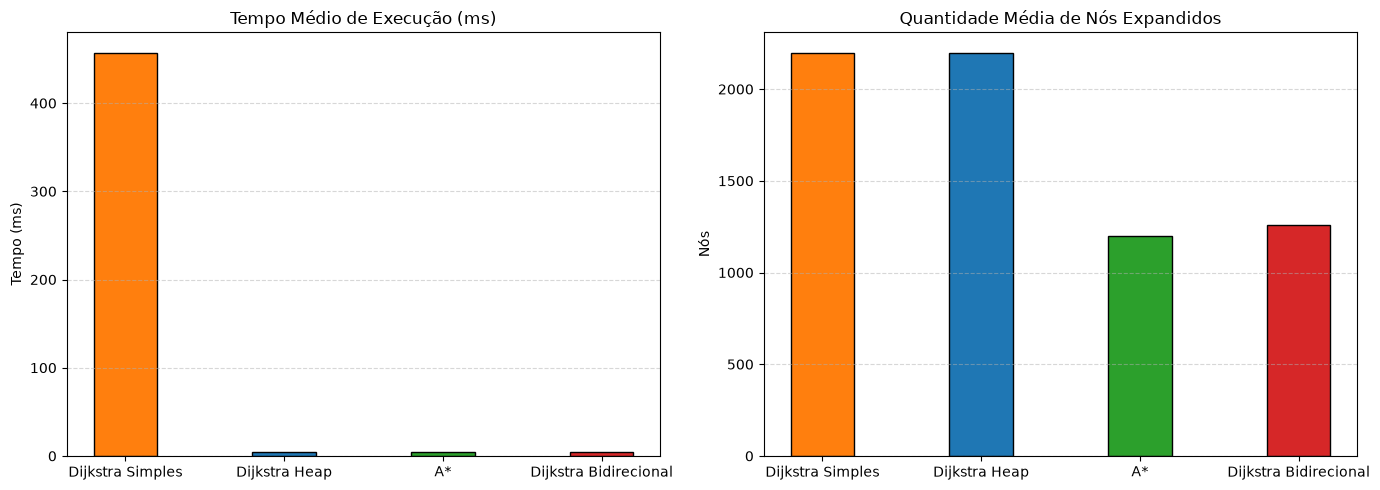

In [79]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728']

ax1.bar(summary_df.index, summary_df['Tempo Médio (ms)'], color=colors, edgecolor='black', width=0.4)
ax1.set_title('Tempo Médio de Execução (ms)')
ax1.set_ylabel('Tempo (ms)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.bar(summary_df.index, summary_df['Nós Expandidos Médios'], color=colors, edgecolor='black', width=0.4)
ax2.set_title('Quantidade Média de Nós Expandidos')
ax2.set_ylabel('Nós')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('img/benchmark_comparison.png', dpi=300)
plt.show()

## 8. Discussão Crítica e Respostas ao Roteiro

Abaixo, respondemos de forma estruturada às 12 questões propostas para análise crítica do trabalho.

### 1. Como o problema foi modelado como grafo?
O problema foi modelado como um grafo direcionado (DiGraph) no qual as ruas são arestas e os cruzamentos representam os nós. Esse formato direcionado é fundamental porque as vias urbanas reais possuem regras de circulação de sentido único e proibições de conversão.

### 2. O que representam os nós e as arestas?
* **Nós ($V$)**: Interseções viárias e finais de linha, identificados por IDs únicos do banco do OpenStreetMap (OSM) e contendo coordenadas geográficas (latitude e longitude) usadas nas heurísticas do A*.
* **Arestas ($E$)**: Trechos físicos de vias públicas. Seus atributos contêm o comprimento da via (`length`), a velocidade máxima permitida (`maxspeed`), e os tempos estimados de tráfego (`time_free_flow` e `time_traffic`).

### 3. Quais pesos foram usados?
Foram estruturados três pesos principais para as arestas no modelo:
* **Distância (`length`)**: O comprimento físico da via em metros, útil para rotas de menor quilometragem total.
* **Tempo Livre (`time_free_flow`)**: Calculado pela razão entre o comprimento e o limite de velocidade regulamentar ($T = L / V_{max}$), indicando a velocidade ideal sem trânsito.
* **Tempo de Trânsito (`time_traffic`)**: Calculado pelo tempo livre multiplicado por fatores de congestionamento sintético.

### 4. Como o trânsito sintético alterou as rotas?
Com a introdução de uma zona de congestionamento de alto fluxo ao redor da UFRN, o simulador adaptou as rotas para contornar a área do campus, selecionando avenidas circundantes de tráfego rápido em vez de vias internas. O trânsito também incentivou o usuário a caminhar mais, já que embarcar perto da região engarrafada gerava um atraso muito maior ao veículo.

### 5. Caminhar alguns metros melhorou a solução?
Sim. Em cenários nos quais a origem estava em uma rua sem saída, em vias internas de trânsito lento, ou em vias que exigiam longas voltas no trânsito para dar retorno, caminhar de 200 a 500 metros permitiu que o usuário embarcasse diretamente em uma avenida de fluxo rápido ou fora do congestionamento, economizando minutos no tempo total de viagem.

### 6. Em quais casos caminhar atrapalhou?
Caminhar torna-se desvantajoso quando a via da origem $A$ já possui fluxo livre e rápido, ou quando o destino está geograficamente na direção oposta ao deslocamento a pé. Como a velocidade da caminhada ($1.2\text{ m/s}$) é muito menor que a do carro, qualquer passo desnecessário reduz a eficiência. No entanto, o otimizador contorna isso selecionando a origem $A$ como ponto de embarque ($P = A$) quando a caminhada não traz benefícios.

### 7. A menor distância foi também a rota mais rápida?
Muitas vezes não. Caminhos de menor distância física tendem a priorizar atalhos residenciais ou vias locais de menor velocidade. Em contrapartida, as rotas otimizadas por tempo preferem avenidas arteriais mais longas em termos de distância, mas que permitem velocidades de circulação muito maiores, principalmente ao simular tráfego pesado nas vias locais.

### 8. O A* expandiu menos nós que o Dijkstra?
Sim, de forma consistente. Como o A* utiliza uma estimativa da distância restante até o alvo (heurística de Haversine) somada à distância percorrida, ele restringe consideravelmente a busca lateral. O Dijkstra Heap expande nós em círculos concêntricos a partir da origem, enquanto o A* concentra a expansão em uma elipse direcionada ao destino final.

### 9. O Dijkstra com Heap foi mais eficiente que o Dijkstra simples?
Sim, houve uma diferença gritante de desempenho. O Dijkstra simples varre linearmente toda a lista de nós abertos para achar o mínimo a cada iteração, resultando em complexidade $O(V^2)$. O Dijkstra com Heap utiliza uma árvore binária de prioridades, reduzindo a complexidade de busca ao mínimo para $O((V+E)\log V)$, o que se traduziu em execuções dezenas de vezes mais velozes nos nossos benchmarks.

### 10. O algoritmo da literatura trouxe algum ganho?
O **Dijkstra Bidirecional** apresentou um desempenho excepcional em termos de espaço de busca. Ao expandir simultaneamente a partir da origem (para a frente) e do destino (para trás), os círculos de busca se encontram na metade do caminho. A área total investigada por duas buscas menores é cerca de metade da área de uma única busca unidirecional completa, resultando em menor quantidade de nós expandidos para caminhos de médio e longo alcance.

### 11. Quais limitações existem na modelagem proposta?
* **Simplificação da Rede de Pedestres**: O usuário caminha na mesma rede de ruas dos carros, ignorando escadarias, faixas de pedestre dedicadas, calçadões ou passarelas.
* **Velocidade Estática**: A velocidade de caminhada é fixa e uniforme ($1.2\text{ m/s}$), sem ponderar topografia (subidas) ou restrições físicas de locomoção.
* **Tráfego Estático**: O trânsito sintético não varia de forma temporal ao longo do percurso da corrida.

### 12. Como o modelo poderia ser aproximado de um aplicativo real de mobilidade?
Poderíamos aproximar o modelo integrando:
1. **Grafos Multimodais**: Baixar e conectar a rede de caminhada (`walk`) e carros (`drive`) de forma separada.
2. **Trânsito Dinâmico em Tempo Real**: Usar APIs de mapas reais (como Waze ou Google Maps) ou bases de dados de GPS históricos para criar perfis horários de trânsito.
3. **Locais Proibidos**: Incluir restrições no grafo para impedir paradas de embarque em locais proibidos, como rodovias de alta velocidade ou faixas exclusivas de ônibus.
4. **Fatores de Segurança**: Penalizar rotas de pedestres em áreas com menor iluminação ou segurança durante períodos noturnos.

## 9. Playground de Consultas Interativas

Utilize esta célula para rodar consultas customizadas em tempo real. Você pode alterar as coordenadas de origem, destino e a distância máxima de caminhada ($X$) e visualizar o mapa resultante na hora.

=================== RESULTADOS DA ROTA ===================
Origem (A):                   (-5.8427, -35.21)
Ponto de Embarque Ideal (P):  Nó 502225328
Destino (B):                  (-5.8118, -35.2052)
----------------------------------------------------------
Distância de Caminhada (A->P): 0.00 metros
Tempo de Caminhada (A->P):     0.0 segundos (0.00 min)
Tempo de Carro (P->B):         352.5 segundos (5.88 min)
----------------------------------------------------------
Tempo TOTAL de Viagem:         352.5 segundos (5.88 min)


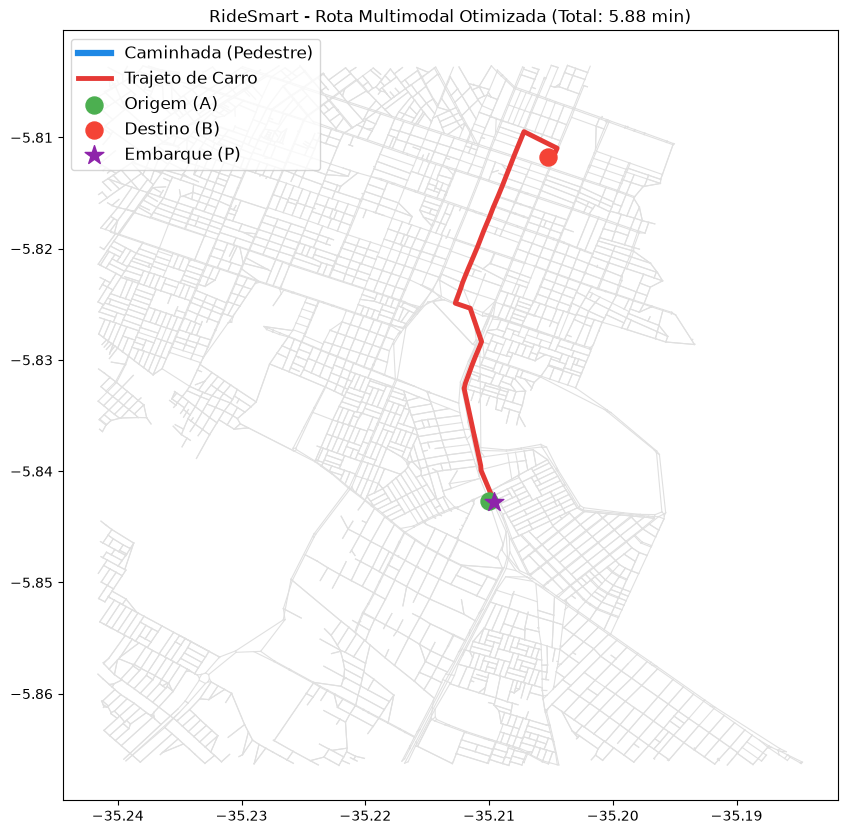

In [80]:
# ==================================================================
# DEFINA AQUI OS PARÂMETROS DA CONSULTA INTERATIVA (TESTE NA HORA):
# ==================================================================
origem = (-5.8427, -35.210)       # (Latitude, Longitude) do ponto A (CT UFRN)
destino = (-5.8118, -35.2052)     # (Latitude, Longitude) do ponto B (Midway Mall)
caminhada_maxima = 300.0          # Distância máxima de caminhada (metros)
# ==================================================================

# Executar a otimização multimodal com os parâmetros digitados
resultado = find_best_pickup_and_route_multimodal(
    G_drive=G_drive,
    G_walk=G_walk,
    transfer_mapping=transfer_mapping,
    start_coords=origem,
    end_coords=destino,
    max_walk_distance=caminhada_maxima,
    walk_speed_mps=1.2,
    weight_field='time_traffic',
    path_algorithm=dijkstra_heap
)

# Exibir os resultados formatados
if resultado['best_pickup_node'] and resultado['drive_path']:
    print("=================== RESULTADOS DA ROTA ===================")
    print(f"Origem (A):                   {origem}")
    print(f"Ponto de Embarque Ideal (P):  Nó {resultado['best_pickup_node']}")
    print(f"Destino (B):                  {destino}")
    print("----------------------------------------------------------")
    print(f"Distância de Caminhada (A->P): {resultado['walk_cost'] * 1.2:.2f} metros")
    print(f"Tempo de Caminhada (A->P):     {resultado['walk_cost']:.1f} segundos ({resultado['walk_cost']/60:.2f} min)")
    print(f"Tempo de Carro (P->B):         {resultado['drive_cost']:.1f} segundos ({resultado['drive_cost']/60:.2f} min)")
    print("----------------------------------------------------------")
    print(f"Tempo TOTAL de Viagem:         {resultado['total_cost']:.1f} segundos ({resultado['total_cost']/60:.2f} min)")
    print("==========================================================")
    
    # Plotar o mapa interativo na tela
    fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')
    ax.set_facecolor('white')
    
    # Plotar malha viária como fundo (desenho manual das arestas de G_drive em cinza)
    for u, v, d_data in G_drive.edges(data=True):
        x1, y1 = G_drive.nodes[u]['x'], G_drive.nodes[u]['y']
        x2, y2 = G_drive.nodes[v]['x'], G_drive.nodes[v]['y']
        ax.plot([x1, x2], [y1, y2], color='#e0e0e0', linewidth=0.8, zorder=3)
    
    # Plotar trecho a pé (azul)
    walk_path = resultado['walk_path']
    if walk_path:
        w_lats = [G_walk.nodes[n]['y'] for n in walk_path]
        w_lons = [G_walk.nodes[n]['x'] for n in walk_path]
        ax.plot(w_lons, w_lats, color='#1e88e5', linewidth=4.5, label='Caminhada (Pedestre)', zorder=5)
        
    # Plotar trecho de carro (vermelho)
    drive_path = resultado['drive_path']
    if drive_path:
        d_lats = [G_drive.nodes[n]['y'] for n in drive_path]
        d_lons = [G_drive.nodes[n]['x'] for n in drive_path]
        ax.plot(d_lons, d_lats, color='#e53935', linewidth=3.5, label='Trajeto de Carro', zorder=4)
        
    # Plotar marcadores especiais
    ax.scatter(origem[1], origem[0], color='#4caf50', s=150, zorder=6, label='Origem (A)')
    ax.scatter(destino[1], destino[0], color='#f44336', s=150, zorder=6, label='Destino (B)')
    
    p_node = resultado['best_pickup_node']
    p_lat, p_lon = G_drive.nodes[p_node]['y'], G_drive.nodes[p_node]['x']
    ax.scatter(p_lon, p_lat, color='#8e24aa', s=200, marker='*', zorder=7, label='Embarque (P)')
    
    ax.legend(loc='upper left', fontsize=12)
    ax.set_title(f"RideSmart - Rota Multimodal Otimizada (Total: {resultado['total_cost']/60:.2f} min)")
    plt.show()
else:
    print("[Erro] Não foi possível traçar uma rota válida com esses parâmetros. Verifique se o limite de caminhada não é muito baixo.")